# Integrable deformations of kaleidocycles

## Goal

Reconstruct a closed anti-oriented kaleidocycle in Cayley-curvature coordinates, evolve it with the two commuting semi-discrete mKdV flows and the semi-discrete sine--Gordon flow, and check the conserved Hamiltonians, closure, frame monodromy, and constant torsion numerically.

## Setup

The implementation uses $\kappa_n=2\tan(\phi_n/2)$ and the twisted convention $x_{n+N}=\sigma x_n$. The sine--Gordon flow requires the anti-periodic sector $\sigma=-1$.

In [1]:
%matplotlib widget
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

notebook_dir = Path(".") if Path("output").is_dir() else Path("notebooks")

from kaleidocycle import (
    critical_multiplier,
    critical_torsion_cosine,
    framed_polygon_from_binormals,
    import_json,
    integrate_curvature_flow,
    mkdv1_field,
    mkdv2_field,
    qrt_invariant,
    variational_recurrence_residual,
)

plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 110})

## Steps

### 1. Extract curvature coordinates from a closed cycle

The source file contains $N+1$ binormals, including the terminal signed copy. Extraction validates unit directions, constant adjacent inner products, and endpoint monodromy.

In [2]:
data_path = notebook_dir / "output/kaleidocycle_k10_nonoriented_bending.json"
cycle = import_json(data_path)
initial = framed_polygon_from_binormals(cycle.hinges)

print(f"N = {initial.curvatures.size}, sign = {initial.sign}")
print(f"torsion angle mu = {initial.torsion_angle:.12f}")
print(f"torsion cosine  = {np.cos(initial.torsion_angle):.3e}")
print(f"closure residual = {np.linalg.norm(initial.closure_residual):.3e}")
print(f"monodromy residual = {np.linalg.norm(initial.monodromy_residual):.3e}")

N = 10, sign = -1
torsion angle mu = 1.570796326795
torsion cosine  = 6.123e-17
closure residual = 2.626e-16
monodromy residual = 0.000e+00


### 2. Integrate all three compatible flows

DOP853 is used with tight tolerances. Each sampled curvature vector is reconstructed using the same initial frame, so residuals can be compared directly.

In [3]:
times = np.linspace(0.0, 0.8, 81)
flow_names = ("mkdv1", "mkdv2", "sine-gordon")
evolutions = {
    name: integrate_curvature_flow(
        initial.curvatures,
        initial.torsion_angle,
        times,
        flow=name,
        sign=initial.sign,
        initial_frame=initial.frames[0],
    )
    for name in flow_names
}

for name, evolution in evolutions.items():
    print(name, evolution.curvatures.shape)

mkdv1 (81, 10)
mkdv2 (81, 10)
sine-gordon (81, 10)


## Checks

### 3. Verify conservation and global constraints

In [4]:
diagnostics = {}
for name, evolution in evolutions.items():
    configurations = evolution.configurations()
    diagnostics[name] = {
        "E1 drift": np.ptp(evolution.first_hamiltonian),
        "E2 drift": np.ptp(evolution.second_hamiltonian),
        "max closure": max(np.linalg.norm(c.closure_residual) for c in configurations),
        "max monodromy": max(np.linalg.norm(c.monodromy_residual) for c in configurations),
        "max torsion error": max(
            np.max(np.abs(
                np.einsum("ij,ij->i", c.binormals[:-1], c.binormals[1:])
                - np.cos(c.torsion_angle)
            ))
            for c in configurations
        ),
    }

for name, values in diagnostics.items():
    print(f"{name:12s} " + "  ".join(f"{key}={value:.2e}" for key, value in values.items()))

mkdv1        E1 drift=3.24e-10  E2 drift=1.29e-16  max closure=5.36e-10  max monodromy=4.86e-10  max torsion error=4.08e-16
mkdv2        E1 drift=8.88e-16  E2 drift=9.10e-17  max closure=2.88e-15  max monodromy=1.02e-15  max torsion error=4.52e-16
sine-gordon  E1 drift=4.29e-10  E2 drift=1.20e-16  max closure=6.51e-10  max monodromy=6.66e-10  max torsion error=6.78e-16


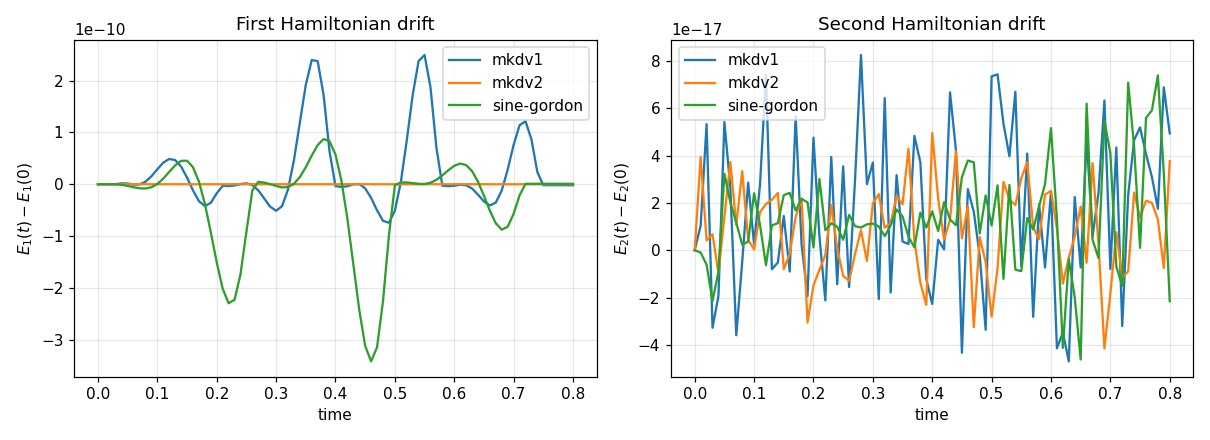

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, evolution in evolutions.items():
    axes[0].plot(times, evolution.first_hamiltonian - evolution.first_hamiltonian[0], label=name)
    axes[1].plot(times, evolution.second_hamiltonian - evolution.second_hamiltonian[0], label=name)
axes[0].set(title="First Hamiltonian drift", xlabel="time", ylabel=r"$E_1(t)-E_1(0)$")
axes[1].set(title="Second Hamiltonian drift", xlabel="time", ylabel=r"$E_2(t)-E_2(0)$")
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
fig.tight_layout()

### 4. Inspect the variational one-degree-of-freedom reduction

This optimized example lies numerically on the Lagrange-critical recurrence. The paper predicts $\lambda=2c+E_2/N$, a constant QRT invariant, and $X^{(2)}=\lambda X^{(1)}$ on this locus.

In [6]:
critical_cosine = critical_torsion_cosine(initial.curvatures, sign=initial.sign)
multiplier = critical_multiplier(initial.curvatures, critical_cosine, sign=initial.sign)
recurrence_error = np.linalg.norm(
    variational_recurrence_residual(initial.curvatures, multiplier, sign=initial.sign),
    ord=np.inf,
)
qrt_drift = np.ptp(qrt_invariant(initial.curvatures, multiplier, sign=initial.sign))
dependent_flow_error = np.linalg.norm(
    mkdv2_field(initial.curvatures, sign=initial.sign)
    - multiplier * mkdv1_field(initial.curvatures, sign=initial.sign),
    ord=np.inf,
)
print(f"critical c: {critical_cosine:.3e} (geometric c: {np.cos(initial.torsion_angle):.3e})")
print(f"lambda: {multiplier:.3e}")
print(f"recurrence residual: {recurrence_error:.3e}")
print(f"QRT drift: {qrt_drift:.3e}")
print(f"X2 - lambda X1: {dependent_flow_error:.3e}")

critical c: 2.665e-16 (geometric c: 6.123e-17)
lambda: 5.086e-16
recurrence residual: 1.551e-07
QRT drift: 2.746e-08
X2 - lambda X1: 4.933e-08


### 5. Compare the resulting centre-line polygons

The curves are translated to their centroids only for display; the reconstruction itself remains based at the original vertex and frame.

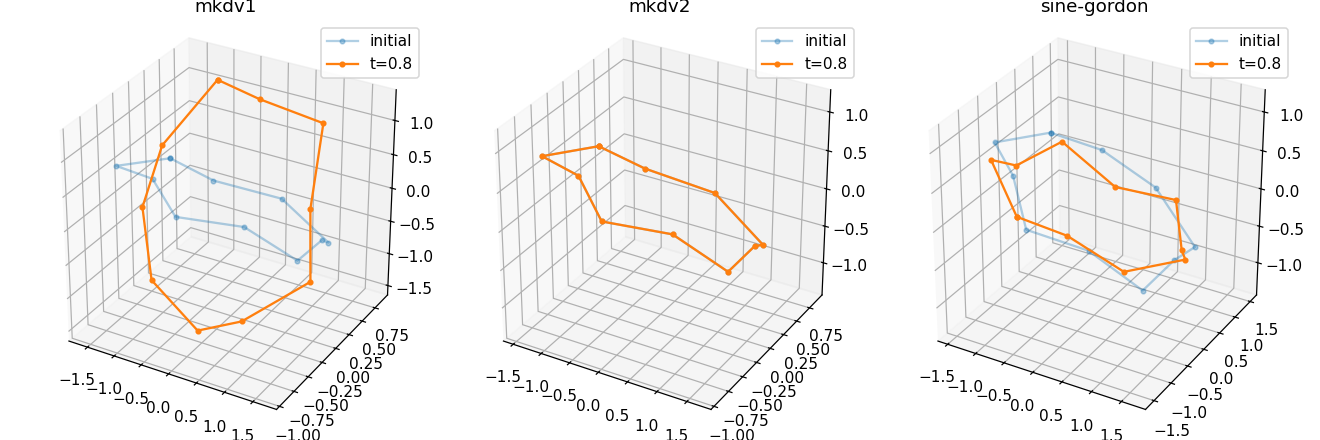

In [7]:
fig = plt.figure(figsize=(12, 4))
for column, name in enumerate(flow_names, start=1):
    axis = fig.add_subplot(1, 3, column, projection="3d")
    final = evolutions[name].configuration(-1)
    for vertices, label, alpha in (
        (initial.vertices, "initial", 0.35),
        (final.vertices, "t=0.8", 1.0),
    ):
        centered = vertices - vertices[:-1].mean(axis=0)
        axis.plot(*centered.T, marker="o", markersize=3, alpha=alpha, label=label)
    axis.set_title(name)
    axis.set_box_aspect((1, 1, 1))
    axis.legend()
fig.tight_layout()

## Next Steps

- Increase the time interval or sampling density to explore complete trajectories.
- Replace the input JSON with another optimized constant-torsion cycle; use `mkdv1` or `mkdv2` for either monodromy sign.
- Use `lift_coefficients` or `lifted_velocities` to inspect the compatible frame, vertex, and binormal velocities.
- Use `variational_recurrence_residual` and `qrt_invariant` to study the invariant one-degree-of-freedom reduction.